In [2]:
import numpy as np
import astropy.units as u
from astropy.io import fits
from astropy.wcs import WCS
import matplotlib.pyplot as plt
from astropy.visualization import simple_norm
from astropy.coordinates import SkyCoord, Galactic
%matplotlib widget

file = "hi4pi-hvc-vlsr-gal-car.fits"
hdul = fits.open(file)
hdr = hdul[0].header
data = hdul[0].data
wcs = WCS(hdr)
norm = simple_norm(data, "linear")


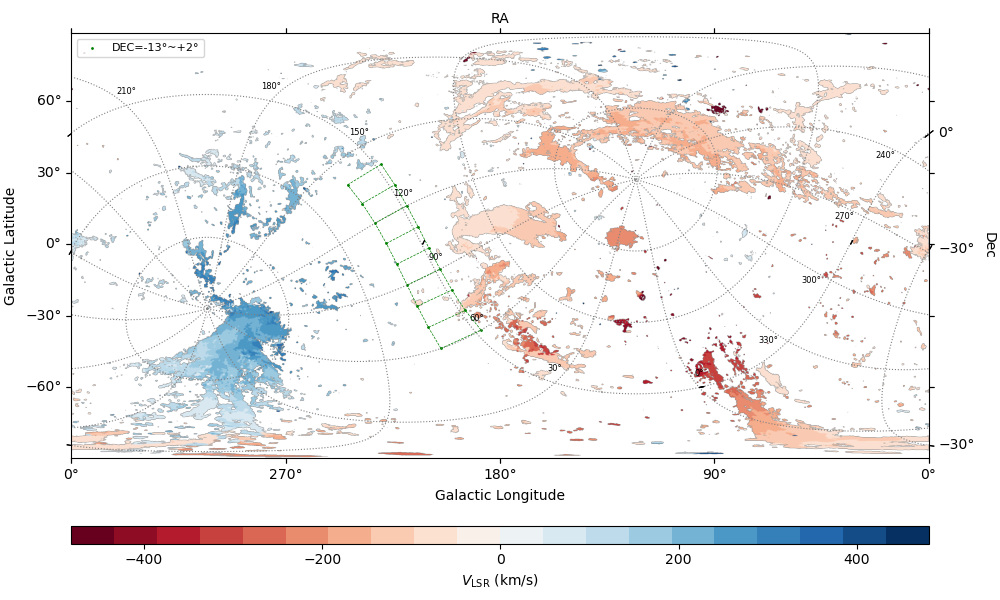

In [7]:
# Plot image on axes ax

fig, ax = plt.subplots(figsize=(10, 6), layout="compressed", subplot_kw={"projection": wcs})
cmap = plt.get_cmap("RdBu", 20)
im = ax.imshow(data, cmap=cmap)
ax.set_xlabel("Galactic Longitude")
ax.set_ylabel("Galactic Latitude")

# Plot dots on axes ax

bound_RA_1 = np.arange(60, 150, 10) * u.degree
bound_DEC_1 = np.arange(-13, 3, 15) * u.degree
bound_RA_1, bound_DEC_1 = np.meshgrid(bound_RA_1, bound_DEC_1)
bound_1 = SkyCoord(bound_RA_1, bound_DEC_1, frame="icrs")
bound_1_gal = bound_1.transform_to(Galactic())

x_1, y_1 = wcs.all_world2pix(bound_1_gal.l, bound_1_gal.b, 0)
ax.scatter(x_1, y_1, s=1, color="green", label="DEC=-13°~+2°")
for i in range(x_1.shape[0]):
    ax.plot(x_1[i], y_1[i], lw=0.5, color="green", ls="dashed")
for i in range(x_1.shape[1]):
    ax.plot(x_1[:, i], y_1[:, i], lw=0.5, color="green", ls="dashed")

# Plot dots on axes ax

# bound_RA_2 = np.arange(10, 100, 10) * u.degree
# bound_DEC_2 = np.arange(17, 47, 10) * u.degree
# bound_RA_2, bound_DEC_2 = np.meshgrid(bound_RA_2, bound_DEC_2)
# bound_2 = SkyCoord(bound_RA_2, bound_DEC_2, frame="icrs")
# bound_2_gal = bound_2.transform_to(Galactic())
#
# x_2, y_2 = wcs.all_world2pix(bound_2_gal.l, bound_2_gal.b, 0)
# ax.scatter(x_2, y_2, s=1, color="blue", label="DEC=+17°~+37°")
# for i in range(x_2.shape[0]):
#     ax.plot(x_2[i], y_2[i], lw=0.5, color="blue", ls="dashed")
# for i in range(x_2.shape[1]):
#     ax.plot(x_2[:, i], y_2[:, i], lw=0.5, color="blue", ls="dashed")

# Plot test image coordinate

# bound_test = SkyCoord(231.404497, 9.086271, frame="galactic", unit="deg")
# x_test, y_test = wcs.all_world2pix(bound_test.l, bound_test.b, 0)
# ax.scatter(x_test, y_test, s=30, marker="s", color="red", label="Test Area 1")
#
# bound_test = SkyCoord(221.979459, 4.023751, frame="galactic", unit="deg")
# x_test, y_test = wcs.all_world2pix(bound_test.l, bound_test.b, 0)
# ax.scatter(x_test, y_test, s=30, marker="s", color="red", label="Test Area 2")

# Plot horizontal colorbar

overlay = ax.get_coords_overlay("icrs")
overlay.grid(color="grey", ls="dotted")

overlay["ra"].set_ticks(np.arange(0, 360, 30) * u.deg)
overlay["ra"].set_ticks_position(("const-dec", "t"))
overlay["ra"].set_ticklabel_position(("const-dec", "t"))
overlay["ra"].set_ticklabel(size=6)
overlay["ra"].set_ticks_visible(False)
overlay["ra"].set_axislabel("RA")
overlay["ra"].set_major_formatter("dd")

overlay["dec"].add_tickable_gridline("const-dec", 0 * u.deg)
overlay["dec"].set_axislabel("Dec")

plt.colorbar(im, orientation="horizontal", aspect=50, label=r'$V_{\mathrm{LSR}}\ \mathrm{(km/s)}$')
plt.legend(loc="upper left", fontsize=8)
plt.savefig("area.png", dpi=600, bbox_inches="tight")
plt.show()